# Setup

In [1]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
import mirdata
import pandas as pd

In [2]:
data_home = '../key-datasets'
fmak = mirdata.initialize('fma_keys', data_home=data_home)
beatport_key = mirdata.initialize('beatport_key', data_home=data_home)
beatles = mirdata.initialize('beatles', data_home=data_home)
giantsteps_key = mirdata.initialize('giantsteps_key', data_home=data_home)
guitarset = mirdata.initialize('guitarset', data_home=data_home)
tonality_classicaldb = mirdata.initialize('tonality_classicaldb', data_home=data_home)

In [3]:
fma_tracks = pd.read_csv('../fma_metadata/tracks.csv', index_col=0, header=[0, 1])

In [4]:
fmakv2_df = pd.read_csv('../fma-keys/fmakv2.csv')

# Download (only necessary to run once)

In [45]:
# download partial datasets
fmak.download(partial_download=['metadata'], cleanup=True)
beatport_key.download(partial_download=['metadata'], cleanup=True)
beatles.download(partial_download=['annotations'], cleanup=True)
giantsteps_key.download(partial_download=['metadata'], cleanup=True)
guitarset.download(partial_download=['annotations'], cleanup=True)
tonality_classicaldb.download(partial_download=['keys'], cleanup=True)

904kB [00:01, 581kB/s]                             
2.66MB [00:00, 19.6MB/s]                            
    Unfortunately the audio files of the Beatles dataset are not available
    for download. If you have the Beatles dataset, place the contents into
    a folder called Beatles with the following structure:
        > Beatles/
            > annotations/
            > audio/
    and copy the Beatles folder to ../key-datasets

640kB [00:01, 441kB/s]                             
37.3MB [00:36, 1.06MB/s]                            
632kB [00:01, 491kB/s]                             
696kB [00:01, 522kB/s]                             
    Unfortunately the audio files of the Tonality classicalDB dataset are not available
    for download. If you have the tonality classicalDB audio dataset, place the contents into
    a folder called classicaldb with the following structure:
        > classicaldb/
            > audio/
            > keys/
            > spectrums/
            > HPCPs/
     

In [46]:
len(tonality_classicaldb.track_ids)

881

# Plots

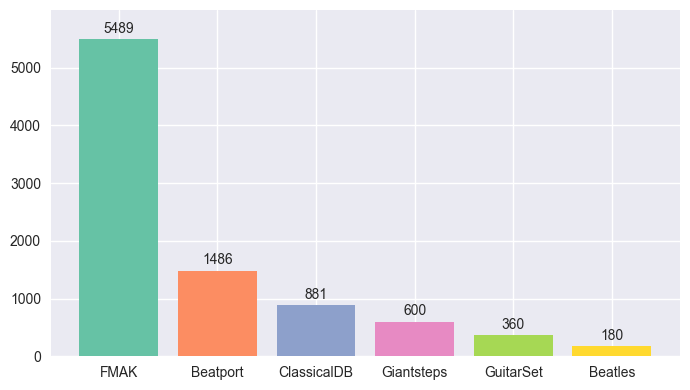

In [9]:
sizes = {
    "FMAK": len(fmak.track_ids),
    "Beatport" : len(beatport_key.track_ids),
    "Beatles": len(beatles.track_ids),
    "Giantsteps": len(giantsteps_key.track_ids),
    "GuitarSet": len(guitarset.track_ids),
    'ClassicalDB': len(tonality_classicaldb.track_ids),
}

sorted_sizes = dict(sorted(sizes.items(), key=lambda item: item[1], reverse=True))
labels = list(sorted_sizes.keys())
values = list(sorted_sizes.values())

plt.figure(figsize=(7, 4))
plt.ylim(0, 5999)
plt.bar(labels, values, color=plt.cm.Set2.colors[:len(labels)])
for i, v in enumerate(values):
    plt.text(i, v + max(values) * 0.01, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../writeup/figs/dataset-sizes.svg', bbox_inches='tight', facecolor='none', format='svg')
plt.show()

In [7]:
fma_genre_top = fma_tracks[('track', 'genre_top')].rename('genre_top')
fmak_genres = fmakv2_df.merge(fma_genre_top, left_on='track_id', right_index=True, how='left')
fmak_genre_counts = fmak_genres['genre_top'].value_counts().sort_values(ascending=False)
fmak_genre_counts

genre_top
Rock                   872
Electronic             634
Folk                   274
Pop                    153
Hip-Hop                152
Instrumental           129
Classical               53
Experimental            44
International           35
Jazz                    25
Country                 18
Old-Time / Historic     16
Soul-RnB                10
Blues                    8
Easy Listening           1
Name: count, dtype: int64

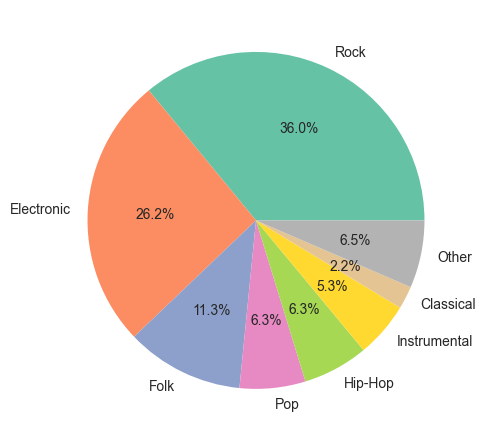

In [10]:
top_n = 7
top_genres = fmak_genre_counts.head(top_n)
other = pd.Series({'Other': fmak_genre_counts.iloc[top_n:].sum()})
pie_data = pd.concat([top_genres, other])

plt.figure(figsize=(5, 5))
plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set2.colors[:len(pie_data)],
)
plt.tight_layout()
plt.savefig('../writeup/figs/fmak-genres.svg', bbox_inches='tight', facecolor='none', format='svg')
plt.show()

In [91]:
num_with_genre = (~fmak_genres['genre_top'].isna()).sum()
prop_with_genre = num_with_genre / len(fmak_genres) * 100
print(f"Proportion of tracks with a top genre: {prop_with_genre:.2f}%")

Proportion of tracks with a top genre: 44.16%
